# Figures for data validation

## Imports

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

## Global `matplotlib` styles

In [2]:
mpl_params = {
    "font.sans-serif": "Helvetica",
    "axes.linewidth": 2,
    "axes.labelsize": 22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 20,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.frameon": False,
}

for k, v in mpl_params.items(): mpl.rcParams[k] = v

## Fetch data

In [3]:
def load_df() -> pd.DataFrame:
    return pd.read_csv(
        "tests/data/test3/output/finalUSA/out_stats.tsv",
        sep="\t",
    ).merge(
        pd.read_csv(
            "tests/data/test3/output/finalUK/out_stats.tsv",
            sep="\t",
        ),
        on="date",
        how="outer",
        suffixes=(" USA", " UK"),
    )

df = load_df()
df.head(n=10)

,date,mean number of mutations USA,var number of mutations USA,size USA,mean number of mutations UK,var number of mutations UK,size UK
0,2020-10-29,NaN,NaN,NaN,34.515152,0.868998,66
1,2020-11-05,NaN,NaN,NaN,35.029412,0.962092,136
2,2020-11-12,NaN,NaN,NaN,35.632509,1.992131,283
3,2020-11-19,NaN,NaN,NaN,36.075758,2.517074,198
4,2020-11-26,NaN,NaN,NaN,36.378261,3.668521,230
5,2020-12-03,NaN,NaN,NaN,36.207048,4.297649,227
6,2020-12-10,NaN,NaN,NaN,36.555866,3.715358,358
7,2020-12-17,NaN,NaN,NaN,37.040625,4.709943,320
8,2020-12-24,33.976190,3.731127,42.0,37.450172,6.579405,291
9,2020-12-31,34.192308,2.546953,78.0,37.649068,6.614781,322


In [4]:
def load_models() -> dict[str, dict[str, callable]]:
    _kinds = ("USA", "UK")
    _file = "tests/data/test3/output/final{}/out_regression_results.json"

    _contents = {}

    for k in _kinds:
        with open(_file.format(k)) as f:
            _contents[k] = json.load(f)

    return {
        "USA": {
            "mean": [
                lambda x: (
                    _contents["USA"]["mean number of mutations per 7D model"]["parameters"]["m"]*x
                    + _contents["USA"]["mean number of mutations per 7D model"]["parameters"]["b"]
                ),
                _contents["USA"]["mean number of mutations per 7D model"]["r2"],
            ],
            "var": [
                lambda x: (
                    _contents["USA"]["scaled var number of mutations per 7D model"]["parameters"]["d"]
                    *(x**_contents["USA"]["scaled var number of mutations per 7D model"]["parameters"]["alpha"])
                ),
                _contents["USA"]["scaled var number of mutations per 7D model"]["r2"],
            ]
        },
        "UK": {
            "mean": [
                lambda x: (
                    _contents["UK"]["mean number of mutations per 7D model"]["parameters"]["m"]*x
                    + _contents["UK"]["mean number of mutations per 7D model"]["parameters"]["b"]
                ),
                _contents["UK"]["mean number of mutations per 7D model"]["r2"],
            ],
            "var": [
                lambda x: (
                    _contents["UK"]["scaled var number of mutations per 7D model"]["parameters"]["d"]
                    *(x**_contents["UK"]["scaled var number of mutations per 7D model"]["parameters"]["alpha"])
                ),
                _contents["UK"]["scaled var number of mutations per 7D model"]["r2"],
            ]
        },
    }

models = load_models()

In [5]:
def safe_map(f: callable, x: list[int | float]) -> list[int | float]:
    _results = []
    for el in x:
        try:
            _results.append(f(el))
        except Exception as e:
            print(f"WARNING: {e}")
            _results.append(None)
    return _results

## Plots

/var/folders/kv/fz4ryb714nsd0rwcxs_x9__m0000gn/T/ipykernel_51300/1730654702.py:23: RuntimeWarning: invalid value encountered in scalar power
  *(x**_contents["USA"]["scaled var number of mutations per 7D model"]["parameters"]["alpha"])
/var/folders/kv/fz4ryb714nsd0rwcxs_x9__m0000gn/T/ipykernel_51300/1730654702.py:39: RuntimeWarning: invalid value encountered in scalar power
  *(x**_contents["UK"]["scaled var number of mutations per 7D model"]["parameters"]["alpha"])


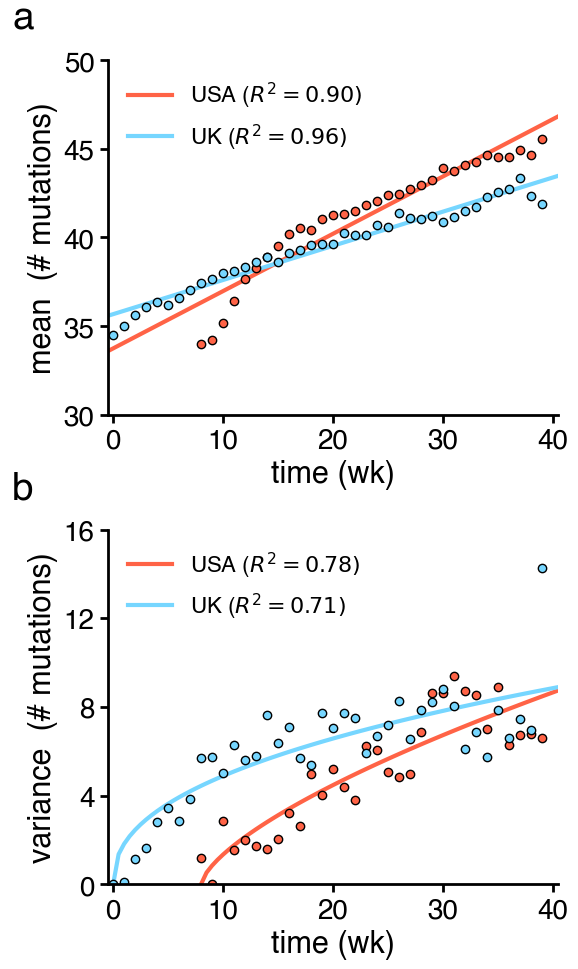

In [6]:
def plot(df: pd.DataFrame, export: bool = False) -> None:
    fig, ax = plt.subplots(2, 1, figsize=(6, 10))

    colors = {
        "UK": "#76d6ff",
        "USA": "#FF6346",
    }

    for idx, case in enumerate(("mean", "var")):
        for col in (f"{case} number of mutations USA", f"{case} number of mutations UK"):

            _country = col.split()[-1].upper()

            ax[idx].scatter(
                df.index,
                df[col] - (df[col].min() if idx == 1 else 0),
                color=colors[_country],
                edgecolor="k",
                zorder=2,   
            )
            
            _x = np.arange(-10, 50, 0.5) 
            ax[idx].plot(
                _x + (8 if _country == "USA" else 0),
                safe_map(models[_country][case][0], _x),
                color=colors[_country],
                label=rf"{_country} ($R^2 = {round(models[_country][case][1], 2):.2f})$",
                linewidth=3,
                zorder=1,
            )

            # Styling
            ax[idx].set_xlim(-0.5, 40.5)
            ax[idx].set_ylim(30, 50) if idx == 0 else ax[idx].set_ylim(0, 16)

            ax[idx].set_xlabel("time (wk)")

            if case == "mean":
                ax[idx].set_ylabel(f"{case}  (# mutations)")
            elif case == "var":
                ax[idx].set_ylabel(f"{case}iance  (# mutations)")
            
            ax[idx].set_xticks(np.arange(0, 41, 10))
            ax[idx].set_yticks(np.arange(30, 51, 5)) if idx == 0 else ax[idx].set_yticks(np.arange(0, 17, 4))

        ax[idx].legend(
            fontsize=16,
            loc="upper left",
        )

    fig.suptitle(" ", fontsize=1) # To get some space on top
    fig.tight_layout()
    plt.annotate("a", (0.02, 0.94), xycoords="figure fraction", fontsize=28, fontweight="bold")
    plt.annotate("b", (0.02, 0.47), xycoords="figure fraction", fontsize=28, fontweight="bold")

    if export:
        fig.savefig(
            "./fig2.pdf",
            dpi=400,
            bbox_inches="tight",
        )

    plt.show()

plot(df, export=True)
